<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9; border-right:5px solid #20639b; padding:8px 18px;">
  <h1 style="color:#173f5f; margin-bottom:4px;">نوت‌بوک 20: Matplotlib پیشرفته با دیتاست Iris</h1>
  <p><b>سطح:</b> متوسط &nbsp; | &nbsp; <b>نوع درس:</b> تکمیلی و کاربردی</p>
  <h3>هدف‌های یادگیری</h3>
  <ul><li>ساخت نمودارهای چندبخشی با subplots</li>
<li>رنگ‌بندی گونه‌ها و ساخت legend</li>
<li>رسم توزیع و boxplot</li>
<li>نمایش ماتریس همبستگی به‌صورت heatmap</li>
<li>افزودن annotation و ذخیرهٔ شکل با کیفیت مناسب</li></ul>
</div>

<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">آماده‌سازی داده</h2>
  <p>همان دیتاست Iris را بارگذاری و نام ستون‌ها را استاندارد می‌کنیم. برای کنترل کامل ظاهر از رابط شیءگرای Matplotlib استفاده می‌کنیم.</p>
</div>

In [2]:
# Load and prepare the Iris dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

bundle = load_iris(as_frame=True)
iris = bundle.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})
iris["species"] = iris["target"].map(dict(enumerate(bundle.target_names)))
iris = iris.drop(columns="target")

colors = {
    "setosa": "#20639b",
    "versicolor": "#3caea3",
    "virginica": "#ed553b",
}
plt.style.use("seaborn-v0_8-whitegrid")


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">Scatter با چند گروه</h2>
  <p>برای هر گونه یک لایهٔ جدا رسم می‌کنیم تا رنگ و legend قابل کنترل باشند. شفافیت نقطه‌ها روی‌هم‌افتادگی را بهتر نشان می‌دهد.</p>
</div>

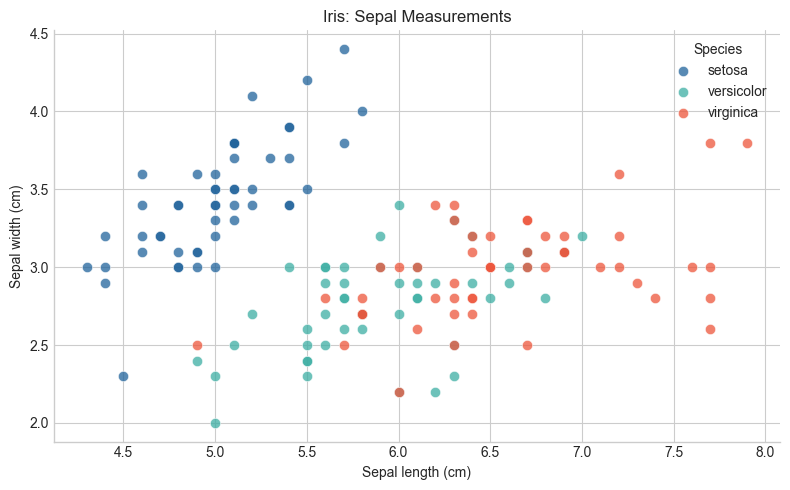

In [3]:
# Plot species as separate scatter layers
fig, ax = plt.subplots(figsize=(8, 5))

for species, group in iris.groupby("species"):
    ax.scatter(
        group["sepal_length"],
        group["sepal_width"],
        label=species,
        color=colors[species],
        alpha=0.75,
        s=55,
        edgecolor="white",
        linewidth=0.5,
    )

ax.set(
    title="Iris: Sepal Measurements",
    xlabel="Sepal length (cm)",
    ylabel="Sepal width (cm)",
)
ax.legend(title="Species", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">Small multiples</h2>
  <p>نمایش چند ویژگی در محورهای جدا اما با طراحی مشترک، مقایسه را ساده می‌کند. محور y مشترک برای نمودارهایی با مقیاس مشابه مفید است.</p>
</div>

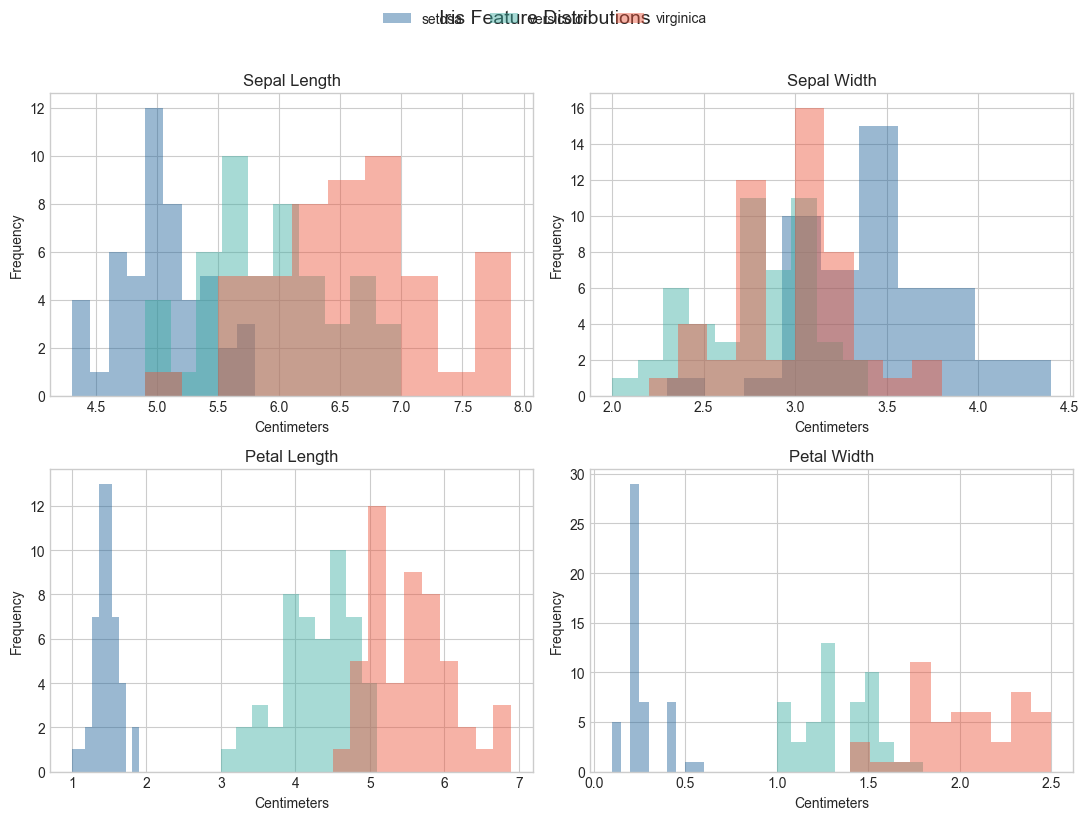

In [4]:
# Compare feature distributions across species
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, feature in zip(axes.flat, features):
    for species, group in iris.groupby("species"):
        ax.hist(
            group[feature],
            bins=10,
            alpha=0.45,
            color=colors[species],
            label=species,
        )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Centimeters")
    ax.set_ylabel("Frequency")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Iris Feature Distributions", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">Boxplot گروهی</h2>
  <p>Boxplot میانه، چارک‌ها، پراکندگی و نقاط دورافتاده را در یک نگاه نشان می‌دهد.</p>
</div>

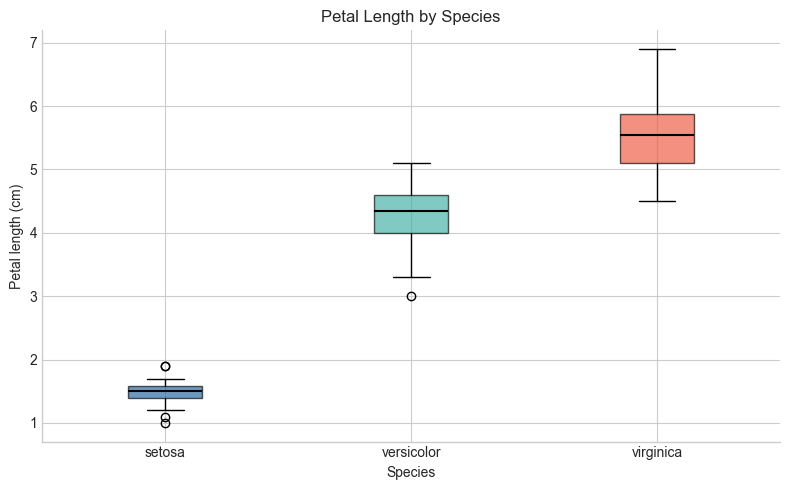

In [5]:
# Draw grouped box plots for petal length
species_order = ["setosa", "versicolor", "virginica"]
grouped_values = [
    iris.loc[iris["species"] == species, "petal_length"]
    for species in species_order
]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(
    grouped_values,
    tick_labels=species_order,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)

for patch, species in zip(box["boxes"], species_order):
    patch.set_facecolor(colors[species])
    patch.set_alpha(0.65)

ax.set(
    title="Petal Length by Species",
    xlabel="Species",
    ylabel="Petal length (cm)",
)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">Heatmap بدون کتابخانهٔ اضافی</h2>
  <p>با <code>imshow</code> می‌توان ماتریس همبستگی را رسم کرد. نوشتن مقدار هر خانه، نمودار را دقیق‌تر می‌کند.</p>
</div>

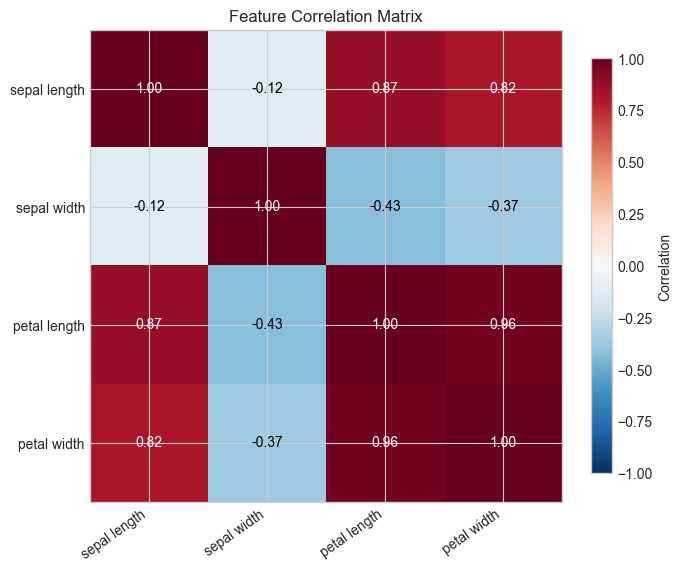

In [6]:
# Visualize the correlation matrix
correlation = iris.select_dtypes(include="number").corr()
labels = [column.replace("_", " ") for column in correlation.columns]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Feature Correlation Matrix")

for row in range(correlation.shape[0]):
    for column in range(correlation.shape[1]):
        value = correlation.iloc[row, column]
        text_color = "white" if abs(value) > 0.65 else "black"
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
        )

fig.colorbar(image, ax=ax, shrink=0.8, label="Correlation")
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">Annotation و برجسته‌سازی</h2>
  <p>Annotation باید نکتهٔ تحلیلی مهم را برجسته کند، نه اینکه نمودار را شلوغ کند. در این مثال بزرگ‌ترین گلبرگ مشخص می‌شود.</p>
</div>

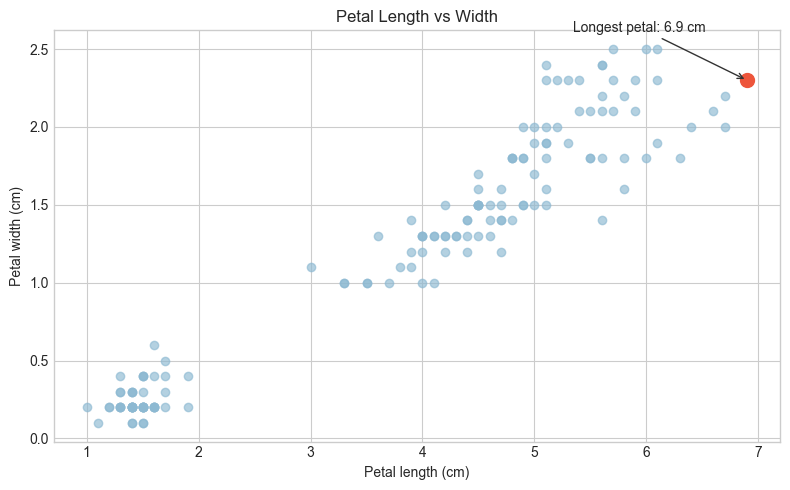

In [7]:
# Highlight the flower with the longest petal
max_index = iris["petal_length"].idxmax()
highlighted = iris.loc[max_index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    iris["petal_length"],
    iris["petal_width"],
    color="#8db9d2",
    alpha=0.65,
)
ax.scatter(
    highlighted["petal_length"],
    highlighted["petal_width"],
    color="#ed553b",
    s=100,
    zorder=3,
)
ax.annotate(
    f"Longest petal: {highlighted['petal_length']:.1f} cm",
    xy=(highlighted["petal_length"], highlighted["petal_width"]),
    xytext=(-125, 35),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#333333"},
)
ax.set(
    title="Petal Length vs Width",
    xlabel="Petal length (cm)",
    ylabel="Petal width (cm)",
)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">ذخیرهٔ شکل</h2>
  <p><code>savefig</code> را پیش از <code>show</code> اجرا کنید. برای گزارش و چاپ، DPI و حاشیهٔ شکل را مشخص کنید. در این مثال فایل موقت ساخته و پاک می‌شود.</p>
</div>

In [8]:
# Save a high-resolution figure to a temporary file
from pathlib import Path
from tempfile import TemporaryDirectory

with TemporaryDirectory() as temp_dir:
    output_path = Path(temp_dir) / "iris_chart.png"
    fig, ax = plt.subplots(figsize=(7, 4))
    means = iris.groupby("species")["petal_length"].mean()
    bars = ax.bar(
        means.index,
        means.values,
        color=[colors[name] for name in means.index],
    )
    ax.bar_label(bars, fmt="%.2f", padding=3)
    ax.set(title="Average Petal Length", ylabel="Centimeters")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    saved_size = output_path.stat().st_size
    plt.close(fig)

print("Saved image bytes:", saved_size)


Saved image bytes: 30997


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">تمرین</h2>
  <div style="background:#fff7df; border:1px solid #f0c36d; padding:12px; border-radius:8px;">یک داشبورد ۱×۲ بسازید: سمت چپ scatter طول و عرض گلبرگ با رنگ گونه‌ها؛ سمت راست میانگین طول گلبرگ هر گونه به‌صورت bar. عنوان کلی و legend اضافه کنید.</div>
</div>

<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">پاسخ پیشنهادی</h2>
  <p>ابتدا پاسخ خودتان را بنویسید و سپس با پاسخ پیشنهادی مقایسه کنید.</p>
</div>

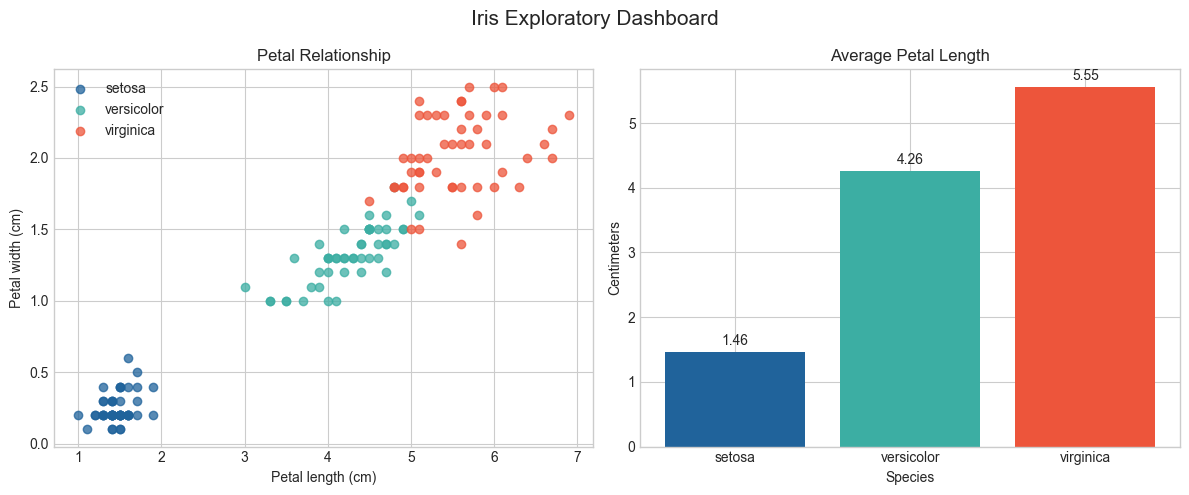

In [9]:
# Build a compact two-panel Iris dashboard
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for species, group in iris.groupby("species"):
    axes[0].scatter(
        group["petal_length"],
        group["petal_width"],
        label=species,
        color=colors[species],
        alpha=0.75,
    )
axes[0].set(
    title="Petal Relationship",
    xlabel="Petal length (cm)",
    ylabel="Petal width (cm)",
)
axes[0].legend(frameon=False)

mean_petals = iris.groupby("species")["petal_length"].mean()
bars = axes[1].bar(
    mean_petals.index,
    mean_petals.values,
    color=[colors[name] for name in mean_petals.index],
)
axes[1].bar_label(bars, fmt="%.2f", padding=3)
axes[1].set(
    title="Average Petal Length",
    xlabel="Species",
    ylabel="Centimeters",
)

fig.suptitle("Iris Exploratory Dashboard", fontsize=15)
fig.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:Tahoma,Arial,sans-serif; line-height:1.9;">
  <h2 style="color:#173f5f;">جمع‌بندی</h2>
  <p>نمودار خوب سؤال مشخص، مقیاس درست، برچسب روشن و کمترین شلوغی لازم را دارد. رنگ و annotation باید معنا را تقویت کنند.</p>
</div>